In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils import resample

## Load & Explore Data

In [2]:
df = pd.read_csv("loan_prediction.csv")
print("DATA TYPES")
print(df.dtypes)
print("\nDESCRIPTIVE STATISTICS")
print(df.describe())
print("\nMISSING VALUES")
print(df.isnull().sum())

DATA TYPES
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

DESCRIPTIVE STATISTICS
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.00

## Data Cleaning

In [3]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("DUPLICATES BEFORE:", df.duplicated().sum())
df = df.drop_duplicates()
print("DUPLICATES AFTER:", df.duplicated().sum())

DUPLICATES BEFORE: 0
DUPLICATES AFTER: 0


## Visualizations & Outlier Removal

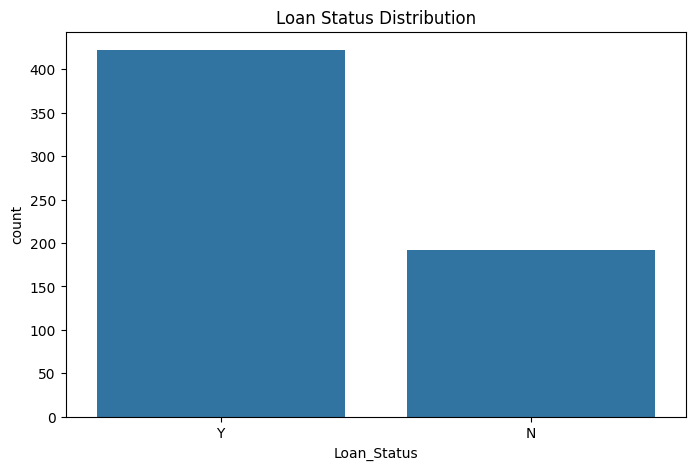

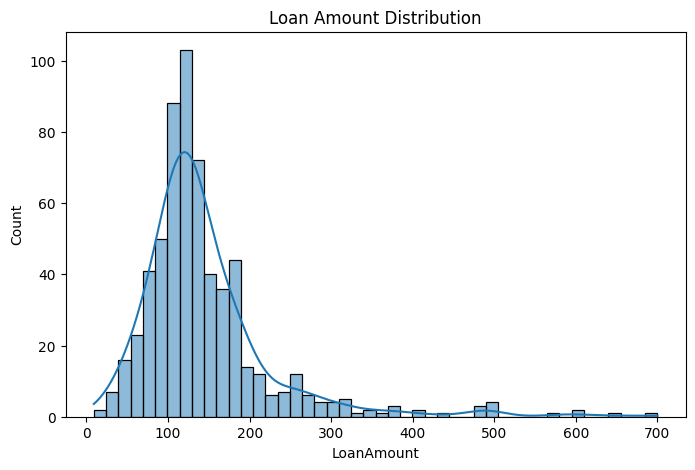

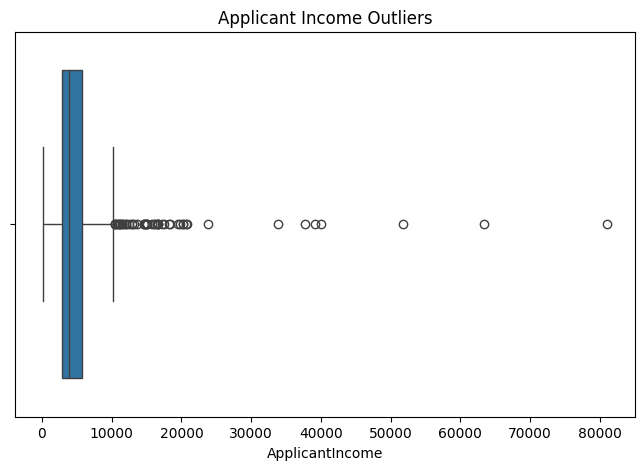

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["LoanAmount"], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["ApplicantIncome"])
plt.title("Applicant Income Outliers")
plt.show()

for col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df = df[(df[col] >= lower) & (df[col] <= upper)]

## Encoding & Balancing

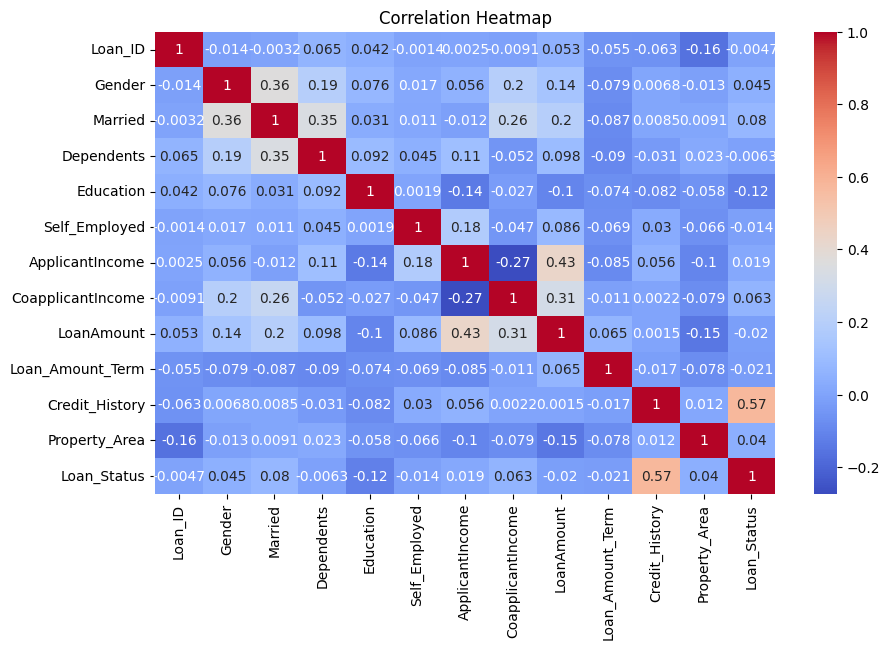

In [5]:
loan_encoder = LabelEncoder()
df["Loan_Status"] = loan_encoder.fit_transform(df["Loan_Status"])

for col in cat_cols:
    if col != "Loan_Status":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

majority = df[df["Loan_Status"] == df["Loan_Status"].mode()[0]]
minority = df[df["Loan_Status"] != df["Loan_Status"].mode()[0]]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
df_balanced = pd.concat([majority, minority_upsampled])

X = df_balanced.drop("Loan_Status", axis=1)
if "Loan_ID" in X.columns:
    X = X.drop("Loan_ID", axis=1)
y = df_balanced["Loan_Status"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Model Training & Comparison

                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.903448   0.902778  0.902778  0.902778
1        Decision Tree  0.896552   0.913043  0.875000  0.893617
0  Logistic Regression  0.731034   0.657143  0.958333  0.779661

BEST MODEL: Random Forest


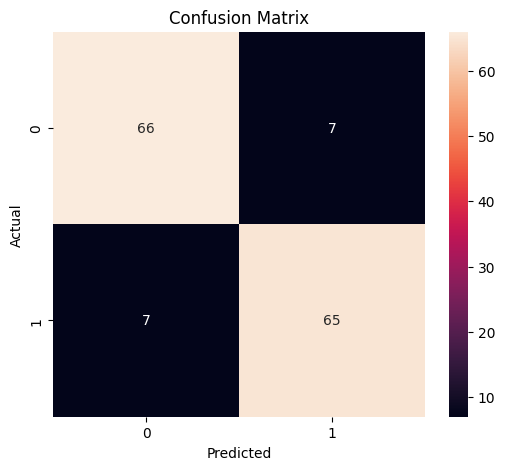

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append([name, accuracy_score(y_test, pred), precision_score(y_test, pred), recall_score(y_test, pred), f1_score(y_test, pred)])

result_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print(result_df.sort_values(by="Accuracy", ascending=False))

best_model_name = result_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
print("\nBEST MODEL:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()